In [10]:
from PIL import Image
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor, ToPILImage

In [11]:
# Here you should put the path of your image
IMAGE_PATH = "../person-3070570300.jpg"

In [12]:
def fix_channels(t):
    """
    Some images may have 4 channels (transparent images) or just 1 channel (black and white images), in order to let the images have only 3 channels. I am going to remove the fourth channel in transparent images and stack the single channel in back and white images.
    :param t: Tensor-like image
    :return: Tensor-like image with three channels
    """
    if len(t.shape) == 2:
        return ToPILImage()(torch.stack([t for i in (0, 0, 0)]))
    if t.shape[0] == 4:
        return ToPILImage()(t[:3])
    if t.shape[0] == 1:
        return ToPILImage()(torch.stack([t[0] for i in (0, 0, 0)]))
    return ToPILImage()(t)

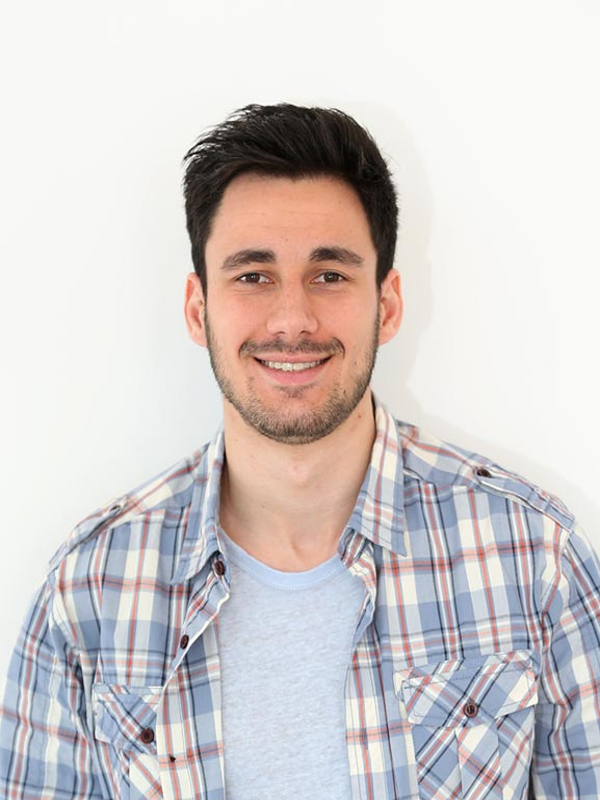

In [13]:
image = Image.open(open(IMAGE_PATH, "rb"))
image = fix_channels(ToTensor()(image))
image = image.resize((600, 800))
image

In [14]:
import numpy as np
from sklearn.cluster import KMeans

def quantize_colors(pil_img, k=3, resize=120):
    """
    Extract dominant colors using K-Means clustering.

    Parameters
    ----------
    pil_img : PIL.Image
        Cropped clothing image.
    k : int
        Number of dominant colors to extract.
    resize : int
        Resize dimension for speed.

    Returns
    -------
    list of tuples
        [(hex_color, percentage), ...]
    """

    img = pil_img.copy()
    img.thumbnail((resize, resize))

    img_data = np.array(img)

    if len(img_data.shape) == 2:
        img_data = np.stack([img_data]*3, axis=-1)

    # Handle RGBA → RGB
    if img_data.shape[-1] == 4:
        img_data = img_data[:, :, :3]

    pixels = img_data.reshape(-1, 3)

    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(pixels)
    centers = kmeans.cluster_centers_.astype(int)

    counts = np.bincount(labels)
    percentages = counts / counts.sum()

    sorted_idx = np.argsort(percentages)[::-1]

    dominant_colors = []
    for i in sorted_idx:
        rgb = tuple(centers[i])
        hex_code = '#{:02X}{:02X}{:02X}'.format(*rgb)
        pct = float(percentages[i])
        dominant_colors.append((hex_code, round(pct, 4)))

    return dominant_colors

In [ ]:
def get_color_name(rgb):
    # Basic CSS3/Web color map
    COLORS = {
        "black": (0, 0, 0),
        "white": (255, 255, 255),
        "gray": (128, 128, 128),
        "red": (220, 20, 60),
        "orange": (255, 140, 0),
        "yellow": (255, 215, 0),
        "green": (34, 139, 34),
        "blue": (30, 144, 255),
        "navy": (0, 0, 128),
        "brown": (139, 69, 19),
        "beige": (245, 245, 220),
        "pink": (255, 105, 180),
        "purple": (128, 0, 128),
    }


    # Find the color with the minimum Euclidean distance
    # Formula: $d = \sqrt{(r_2-r_1)^2 + (g_2-g_1)^2 + (b_2-b_1)^2}$
    min_dist = float('inf')
    best_name = "Unknown"

    for name, target_rgb in COLORS.items():
        dist = np.sqrt(np.sum((np.array(rgb) - np.array(target_rgb))**2))
        if dist < min_dist:
            min_dist = dist
            best_name = name
    return best_name

In [23]:
def quantize_with_names(pil_img, k=7):
    colors = quantize_colors(pil_img, k)
    result = []

    for hex_code, pct in colors:
        rgb = tuple(int(hex_code[i:i+2], 16) for i in (1, 3, 5))
        name = get_color_name(rgb)
        result.append((hex_code, name, pct))

    return result


In [24]:
quantize_with_names(image)

[('#F5F6F3', 'White', 0.4622),
 ('#D4D8DD', 'Beige', 0.1397),
 ('#B4B7C2', 'Khaki', 0.1342),
 ('#DEA891', 'Khaki', 0.0981),
 ('#9397A7', 'Grey', 0.087),
 ('#8D6F65', 'Grey', 0.0457),
 ('#2A221E', 'Black', 0.033)]